In [1]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
store = pd.read_csv("../data/raw/store.csv")

print(train.shape)
print(store.shape)

train.head()

(1017209, 9)
(1115, 10)


C:\Users\DELL\AppData\Local\Temp\ipykernel_19444\2543767421.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
print('Shape of train dataset:', train.shape)
print('Shape of store dataset:', store.shape)

print('Columns in train dataset:\n', train.columns)
train.head()
print('Columns in store dataset:\n', store.columns)
store.head()

print('\nInformation about train dataset:\n')
train.info()

print('\nInformation about store dataset:\n')
store.info()

Shape of train dataset: (1017209, 9)
Shape of store dataset: (1115, 10)
Columns in train dataset:
 Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='str')
Columns in store dataset:
 Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

Information about train dataset:

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          

In [11]:
train["Sales"].value_counts().head(10)

Sales
0       172871
5674       215
5558       197
5483       196
6049       195
6214       195
5723       194
5449       192
5489       191
5140       191
Name: count, dtype: int64

In [8]:
train[train["Sales"] == 0]["Open"].value_counts()

Open
0    172817
1        54
Name: count, dtype: int64

In [9]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [15]:
train["Date"] = pd.to_datetime(train["Date"])
print(train["Date"].min())
print(train["Date"].max())



2013-01-01 00:00:00
2015-07-31 00:00:00


In [16]:
train["Date"].nunique()

942

In [18]:
daily_sales = (
    train.groupby("Date")["Sales"]
    .sum()
    .reset_index()
)
print(daily_sales.head())
print(daily_sales.shape)

        Date    Sales
0 2013-01-01    97235
1 2013-01-02  6949829
2 2013-01-03  6347820
3 2013-01-04  6638954
4 2013-01-05  5951593
(942, 2)


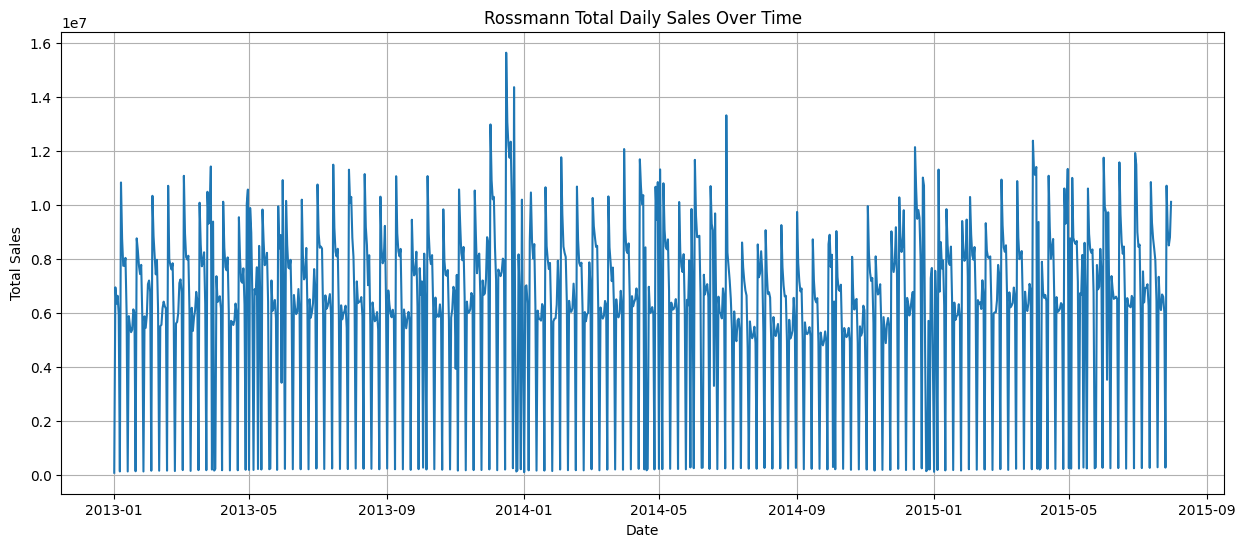

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title("Rossmann Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

In [20]:
daywise_sales = (
    train.groupby("DayOfWeek")["Sales"]
    .mean()
    .reset_index()
)

print(daywise_sales)

   DayOfWeek        Sales
0          1  7809.044510
1          2  7005.244467
2          3  6555.884138
3          4  6247.575913
4          5  6723.274305
5          6  5847.562599
6          7   204.183189


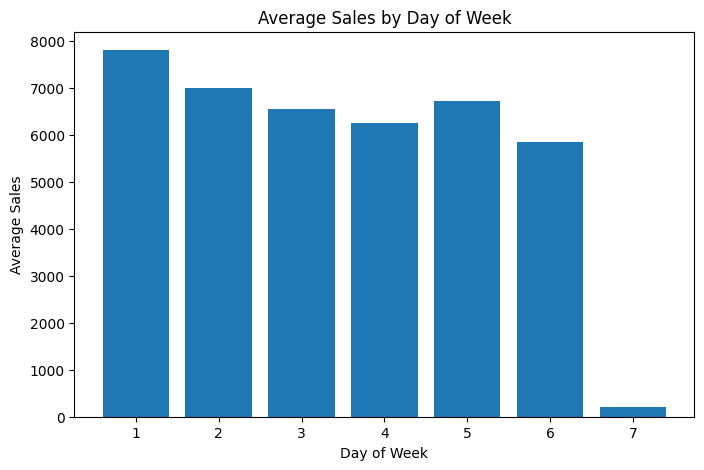

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    daywise_sales["DayOfWeek"],
    daywise_sales["Sales"]
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.show()

In [23]:
train.loc[0, ["Date", "DayOfWeek"]]

Date         2015-07-31 00:00:00
DayOfWeek                      5
Name: 0, dtype: object

In [24]:
pd.Timestamp("2015-07-31").day_name()

'Friday'

In [25]:
train.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    5733.530624
0    5980.279717
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64

In [26]:
train["StateHoliday"].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [27]:
train["StateHoliday"] = train["StateHoliday"].astype(str)

In [28]:
train["StateHoliday"].unique()

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str

In [29]:
train["StateHoliday"] = train["StateHoliday"].astype(str)

train["StateHoliday"] = train["StateHoliday"].replace({
    "0": "No Holiday",
    "a": "Public Holiday",
    "b": "Easter Holiday",
    "c": "Christmas Holiday"
})

In [30]:
train["StateHoliday"].unique()

<StringArray>
['No Holiday', 'Public Holiday', 'Easter Holiday', 'Christmas Holiday']
Length: 4, dtype: str

In [31]:
train.groupby("Promo")["Sales"].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [32]:
train.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64

In [33]:
train_store = train.merge(
    store,
    on="Store",
    how="left"
)

print(train_store.shape)

(1017209, 18)


In [34]:
train_store.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)

StoreType
b    10058.837334
a     5738.179710
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64

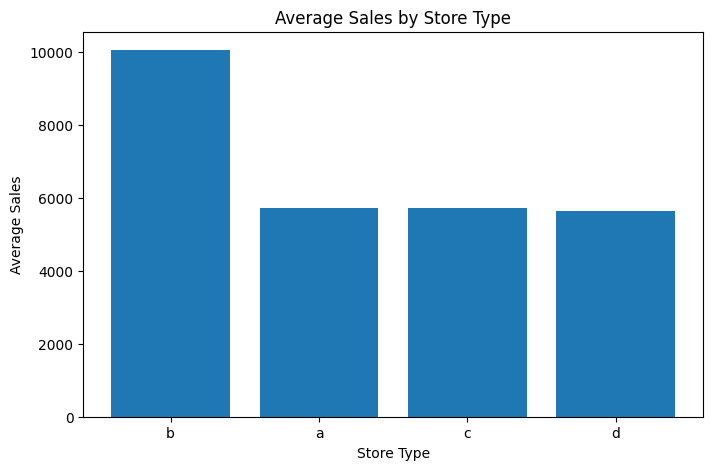

In [35]:
import matplotlib.pyplot as plt

storetype_sales = (
    train_store.groupby("StoreType")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(
    storetype_sales.index,
    storetype_sales.values
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

In [36]:
train_store.groupby("Assortment")["Sales"].mean().sort_values(ascending=False)

Assortment
b    8553.931999
c    6058.676567
a    5481.026096
Name: Sales, dtype: float64

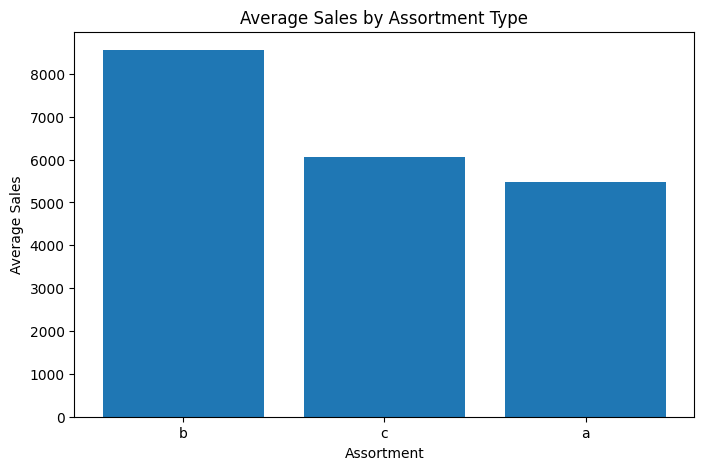

In [37]:
assortment_sales = (
    train_store.groupby("Assortment")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
plt.bar(
    assortment_sales.index,
    assortment_sales.values
)

plt.title("Average Sales by Assortment Type")
plt.xlabel("Assortment")
plt.ylabel("Average Sales")

plt.show()

In [38]:
train_store["CompetitionDistance"].describe()

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64

In [39]:
train_store["CompetitionCategory"] = pd.qcut(
    train_store["CompetitionDistance"],
    q=4,
    labels=[
        "Very Close",
        "Close",
        "Moderate",
        "Far"
    ]
)

In [40]:
competition_sales = (
    train_store
    .groupby("CompetitionCategory")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(competition_sales)

CompetitionCategory
Very Close    6096.122781
Close         5758.126957
Far           5680.287231
Moderate      5570.358664
Name: Sales, dtype: float64


In [41]:
train_store.groupby("Promo2")["Sales"].mean()

Promo2
0    6124.710161
1    5423.718218
Name: Sales, dtype: float64